In [207]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

from matplotlib.patches import Circle

import numpy as np
from tqdm import tqdm
import math

In [208]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device used:", device)

Device used: cuda


In [209]:
### Downloading MNIST

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

print(f"Size of train dataset: {len(train_dataset)}")
print(f"Size of test dataset: {len(test_dataset)}")

Size of train dataset: 60000
Size of test dataset: 10000


In [210]:
### Datasets and Dataloaders

train_indices = [i for i, (_, label) in enumerate(train_dataset) if label in [0, 1, 8]]
test_indices = [i for i, (_, label) in enumerate(test_dataset) if label in [0, 1, 8]]

train_dataset = Subset(train_dataset, train_indices)
test_dataset = Subset(test_dataset, test_indices)

print(f"Size of train dataset: {len(train_dataset)}")
print(f"Size of test dataset: {len(test_dataset)}")

# train_dataset = Subset(train_dataset,range(50))
# test_dataset = Subset(test_dataset,range(10))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

Size of train dataset: 18516
Size of test dataset: 3089


In [211]:
true_train_labels = []
true_test_labels = []
for _,labels in train_loader:
    true_train_labels.append(labels)

for _,labels in train_loader:
    true_test_labels.append(labels)

true_train_labels = torch.concat(true_train_labels)
true_test_labels = torch.concat(true_test_labels)

In [212]:
class RBF_Variance(nn.Module):
    def __init__(self, output_dim,vae_model,train_loader,K,curv_control=2):
        super().__init__()
        self.a = curv_control
        self.centers, self.bandwidths = self.fit_kmeans(vae_model=vae_model,train_loader=train_loader,K=K)
        self.num_centers = self.centers.shape[0]
        self.fc = nn.Linear(self.num_centers, output_dim,bias=False)                       # remplace W et b

    def fit_kmeans(self,vae_model,train_loader,K):
        vae_model.eval()

        latents = []
        labels = []

        with torch.no_grad():
            for data, label in train_loader:
                data = data.to(device)
                mu, _ = vae_model.encode(data)
                latents.append(mu.cpu())
                labels.append(label)

        Z = torch.cat(latents, dim=0).numpy()
        Y = torch.cat(labels, dim=0).numpy()

        gmm = GaussianMixture(n_components=K, covariance_type='spherical', random_state=0)
        gmm.fit(Z)

        centers = torch.tensor(gmm.means_).to(device)
        bandwidths = 0.5 * torch.sqrt(self.a * torch.tensor(gmm.covariances_)).to(device)
        return centers, bandwidths

    def forward(self, z):
        # z: [batch, latent_dim]
        z.to(device)
        diff = z.unsqueeze(1) - self.centers.unsqueeze(0)      # [batch, K, latent_dim]
        dist2 = torch.sum(diff**2, dim=-1) # [batch, K]
        v = torch.exp(- self.bandwidths * dist2)                   # [batch, K]
        Beta = F.softplus(self.fc(v.float())) + 1e-6                            # [batch, output_dim]
        return torch.log(1/Beta)

class ConvVAE(nn.Module):
    def __init__(self,input_dim=1, latent_dim=20,hidden_dims=[512,256], kernel_size=4, height=28,width=28,rbf_model=None):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = input_dim

        self.height = height
        self.width = width

        ### Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.extend([
                nn.Conv2d(prev_dim,h_dim,kernel_size=kernel_size,stride=2,padding=1),
                nn.ReLU(),
            ])
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        ### Parameters
        self.max_depth = len(hidden_dims)
        total_dim = prev_dim*(height//2**self.max_depth)*(width//2**self.max_depth)
        self.fc_mu = nn.Linear(total_dim,latent_dim)


        self.net_logvar = nn.Linear(total_dim,latent_dim)
        self.rbf_model = rbf_model

        ### Decoder
        self.fc_dec = nn.Linear(latent_dim,total_dim)
        decoder_layers = []

        for h_dim in reversed(hidden_dims[:-1]):
            decoder_layers.extend([
                nn.ConvTranspose2d(prev_dim,h_dim,kernel_size=kernel_size,stride=2,padding=1),
                nn.ReLU()
            ])
            prev_dim = h_dim

        decoder_layers.extend([
            nn.ConvTranspose2d(h_dim,1,kernel_size=kernel_size,stride=2,padding=1),
            nn.Sigmoid()
        ])

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self,x):
        h = self.encoder(x)
        h = h.view(x.size(0),-1) # (BATCH_SIZE, VECTORED_IMG_DIM)

        mu = self.fc_mu(h)
        if(self.rbf_model):
            logvar = self.rbf_model(mu)
        else:
            logvar = self.net_logvar(h)

        return mu,logvar

    def reparametrize(self,mu,logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self,z):
        h = self.fc_dec(z)
        h = h.view(z.size(0),-1,self.width//2**self.max_depth,self.height//2**self.max_depth)
        return self.decoder(h)

    def forward(self,x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu,logvar)
        x_hat = self.decode(z)

        return x_hat,z,mu,logvar

    def add_rbf(self,rbf_model):
        for p in rbf_model.parameters():
            p.requires_grad = False

        self.rbf_model = rbf_model

    def compute_metric_tensor_simple(self, z,eps=1e-6):
        """Simplified metric computation using finite differences"""
        batch_size = z.shape[0]
        C = self.input_dim # channels (for colors)
        M = torch.zeros(batch_size,C, self.latent_dim, self.latent_dim).to(z.device)

        with torch.no_grad():
            f0 = self.decode(z).squeeze(0)
            for i in range(self.latent_dim):
                z_plus = z.clone()
                z_plus[:, i] += eps
                f_plus = self.decode(z_plus).squeeze(0)
                grad_i = (f_plus - f0) / eps

                for j in range(self.latent_dim):
                    z_plus_j = z.clone()
                    z_plus_j[:, j] += eps
                    f_plus_j = self.decode(z_plus_j).squeeze(0)
                    grad_j = (f_plus_j - f0) / eps
                    M[:,:, i, j] = torch.sum(grad_i * grad_j, dim=(-2,-1))

        eye = torch.eye(self.latent_dim, device=z.device).unsqueeze(0).unsqueeze(1)
        M = M + 1e-3 * eye

        return M


def vae_loss(x_hat, x, mu, logvar):
    recon = F.binary_cross_entropy(x_hat, x, reduction='sum')

    ### z must be drawn from N(0,I)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon + kl


def load_vae(model_path,latent_dim):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConvVAE(latent_dim=latent_dim).to(device)
    state_dict = torch.load(
        model_path,
        map_location=device
    )

    model.load_state_dict(state_dict)
    return model

def train_vae(train_loader,val_loader,latent_dim=20,lr=1e-3,epochs=20,val_freq=5,rbf_model=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ConvVAE(latent_dim=latent_dim,rbf_model=rbf_model).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    pbar = tqdm(range(epochs),desc="Training VAE:")
    val_loss = torch.inf
    train_loss_history = []
    val_loss_history = []
    for epoch in pbar:
        model.train()
        total_loss = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad()
            x_hat,_, mu, logvar = model(x)
            loss = vae_loss(x_hat, x, mu, logvar)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % val_freq:
            val_loss = val_vae(model,val_loader=val_loader)

        train_loss = total_loss / len(train_loader)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        pbar.set_postfix({"train loss": f"{train_loss:.4f}", "val loss": f"{val_loss:.4f}"})

    return model,train_loss_history,val_loss_history

def val_vae(model,val_loader):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)

            x_hat,_, mu, logvar = model(x)
            loss = vae_loss(x_hat, x, mu, logvar)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    return val_loss


def rbf_loss(logvar,logvar_hat):
    loss = torch.nn.MSELoss(reduction='mean')(logvar, logvar_hat)
    return loss


def train_rbf(vae_model,train_loader,val_loader,latent_dim=20,lr=1e-3,epochs=20,val_freq=5,curv_control=2,K=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    rbf_model = RBF_Variance(output_dim=latent_dim,vae_model=vae_model,train_loader=train_loader,K=K,curv_control=curv_control).to(device)
    optimizer = torch.optim.Adam(rbf_model.parameters(), lr=lr)

    vae_model.eval()

    pbar = tqdm(range(epochs),desc="Training RBF:")
    val_loss = torch.inf
    train_loss_history = []
    val_loss_history = []
    for epoch in pbar:
        rbf_model.train()
        total_loss = 0

        for x, _ in train_loader:
            x = x.to(device)

            optimizer.zero_grad()
            x_hat,x_latent, mu, logvar = vae_model(x)

            logvar_hat = rbf_model(x_latent)

            loss = rbf_loss(logvar,logvar_hat)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % val_freq:
            val_loss = val_rbf(rbf_model=rbf_model,vae_model=vae_model,val_loader=val_loader)

        train_loss = total_loss / len(train_loader)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        pbar.set_postfix({"train loss": f"{train_loss:.4f}", "val loss": f"{val_loss:.4f}"})

    return rbf_model,train_loss_history,val_loss_history

def val_rbf(rbf_model,vae_model,val_loader):
    rbf_model.eval()
    vae_model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)

            x_hat,x_latent, mu, logvar = vae_model(x)

            logvar_hat = rbf_model(x_latent)
            loss = rbf_loss(logvar,logvar_hat)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    return val_loss

def show_loss(train_loss_history,val_loss_history):
    fig =plt.figure()
    plt.plot(train_loss_history,color="red",label="train")
    plt.plot(val_loss_history,color="green",label="val")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [213]:
def plot_rbf_centers(model, train_loader,dim_x=0,dim_y=1, K=15):
    """Plot latent space with RBF centers"""
    model.eval()

    latents = []
    labels = []

    with torch.no_grad():
        for data, label in train_loader:
            data = data.to(device)
            mu, _ = model.encode(data)
            latents.append(mu.cpu())
            labels.append(label)

    Z = torch.cat(latents, dim=0).numpy()
    Y = torch.cat(labels, dim=0).numpy()

    gmm = GaussianMixture(n_components=K, covariance_type='spherical', random_state=0)
    gmm.fit(Z)

    centers = gmm.means_
    lambda_rbf = np.sqrt(gmm.covariances_).mean()

    plt.figure(figsize=(8, 8))
    plt.scatter(Z[:, dim_x], Z[:, dim_y], c=Y, cmap='tab10', s=8, alpha=0.35)
    plt.scatter(centers[:, dim_x], centers[:, dim_y], c='red', marker='x',
                s=150, linewidths=2, label='RBF Centers')

    for c in centers:
        circle = Circle(c, radius=lambda_rbf, fill=False, linestyle='--',
                       edgecolor='red', alpha=0.6)
        plt.gca().add_patch(circle)

    plt.xlabel('z₁', fontsize=12)
    plt.ylabel('z₂', fontsize=12)
    plt.title('Latent Space Coverage via RBF Variance Network', fontsize=14)
    plt.axis('equal')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    return centers,lambda_rbf

In [214]:
!ls /content

data  rbf_model  sample_data  vae_model.pth


In [215]:
training = True
drive = True
latent_dim = 2
if(drive):
    model_path = ".\vae_model.pth"
else:
    model_path = r"C:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Computational statistics\Projet\models\vae_model.pth"

if(training):
    ### Training on MNIST


    training_params = {
        "train_loader": train_loader,
        "val_loader": test_loader,
        "latent_dim": latent_dim,
        "lr": 5*1e-3,
        "epochs":20,
    }

    vae_model, train_loss_history, val_loss_history = train_vae(**training_params)
    torch.save(vae_model.state_dict(), model_path)
else:
    ### Loading a model (trained on MNIST)
    vae_model = load_vae(model_path=model_path,latent_dim=latent_dim) # Check latent dim (has to be same as the saved model)
    train_loss_history, val_loss_history = None, None

Training VAE:: 100%|██████████| 20/20 [04:02<00:00, 12.15s/it, train loss=15708.0448, val loss=15564.9195]


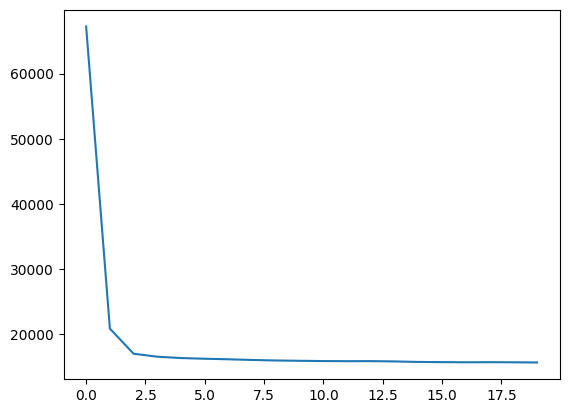

In [216]:
plt.plot(train_loss_history)

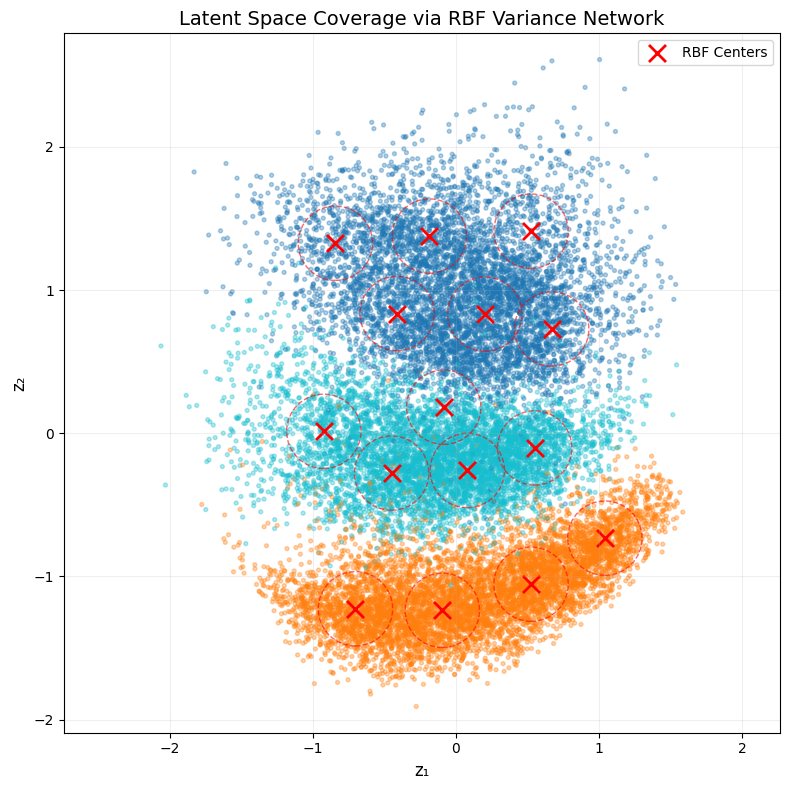

In [217]:
centers = plot_rbf_centers(vae_model,train_loader,dim_x=0,dim_y=1,K=15)

In [218]:
### Train RBF NN
training = True
drive = True

if(training):
    ### Training on MNIST
    latent_dim = 2

    training_params = {
        "vae_model": vae_model,
        "train_loader": train_loader,
        "val_loader": test_loader,
        "latent_dim": latent_dim,
        "lr": 3*1e-3,
        "epochs":15,
        "K":15,
        "curv_control":1
    }

    rbf_model, train_loss_history, val_loss_history = train_rbf(**training_params)
    torch.save(rbf_model.state_dict(), "./rbf_model")
else:
    ### Loading a model (trained on MNIST)
    if(drive):
        model_path = r"C:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Computational statistics\Projet\models\vae_model.pth"
    else:
        model_path = r".\models\vae_model.pth"
    vae_model = load_vae(model_path=model_path,latent_dim=2) # Check latent dim (has to be same as the saved model)
    train_loss_history, val_loss_history = None, None

Training RBF:: 100%|██████████| 15/15 [02:23<00:00,  9.60s/it, train loss=7.9203, val loss=7.7702]


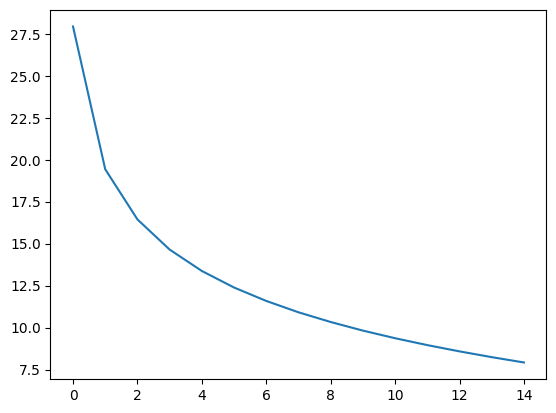

In [219]:
plt.plot(train_loss_history)

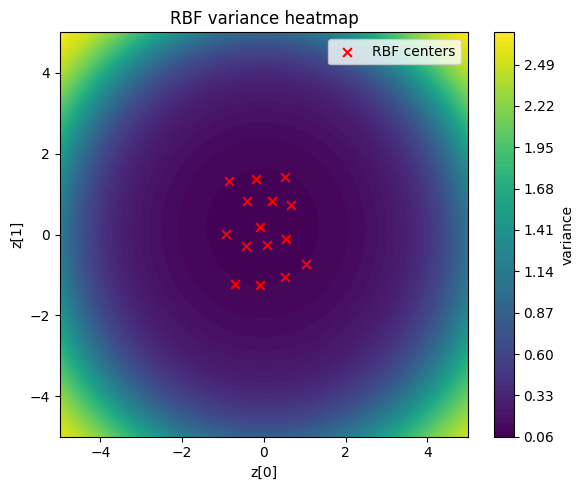

In [243]:
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def plot_rbf_heatmap(
    rbf_model,
    latent_dim=2,
    x_min=-3, x_max=3,
    y_min=-3, y_max=3,
    dim_x=0,
    dim_y=1,
    grid_size=200,
    mode="variance",      # "variance" ou "precision"
    log_scale=False,
    centers=True,
    device=None,
    title=None,
):
    """
    Plot heatmap of RBF variance / precision on a 2D latent slice.

    Parameters
    ----------
    rbf_model : nn.Module
        RBF model returning variance or precision.
    latent_dim : int
        Dimensionality of latent space.
    x_min, x_max, y_min, y_max : float
        Bounds of the 2D latent slice.
    dim_x, dim_y : int
        Latent dimensions to visualize.
    grid_size : int
        Resolution of the grid.
    mode : str
        "variance" or "precision"
    log_scale : bool
        Plot log(variance / precision)
    centers : bool
        Overlay RBF centers
    device : torch.device
    title : str
    """

    device = device or next(rbf_model.parameters()).device

    # Create grid
    xs = torch.linspace(x_min, x_max, grid_size, device=device)
    ys = torch.linspace(y_min, y_max, grid_size, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="ij")

    # Build latent grid
    z = torch.zeros(grid_size * grid_size, latent_dim, device=device)
    z[:, dim_x] = X.reshape(-1)
    z[:, dim_y] = Y.reshape(-1)

    out = rbf_model(z)
    out = torch.sum(torch.exp(out),dim=1)

    Z = out.reshape(grid_size, grid_size)

    plt.figure(figsize=(6, 5))
    plt.contourf(X.cpu(), Y.cpu(), Z.cpu(), levels=100, cmap="viridis")
    plt.colorbar(label=("log " if log_scale else "") + mode)

    if centers and hasattr(rbf_model, "centers"):
        c = rbf_model.centers
        plt.scatter(
            c[:, dim_x].cpu(),
            c[:, dim_y].cpu(),
            c="red",
            s=40,
            marker="x",
            label="RBF centers",
        )
        plt.legend()

    plt.xlabel(f"z[{dim_x}]")
    plt.ylabel(f"z[{dim_y}]")
    plt.title(title or f"RBF {mode} heatmap")
    plt.tight_layout()
    plt.show()


plot_rbf_heatmap(rbf_model=rbf_model,x_min=-5,x_max=5,y_min=-5,y_max=5)

In [221]:
#vae_model.add_rbf(rbf_model=rbf_model)

from torch.utils.data import TensorDataset, DataLoader

vae_model.eval()

### Latents of training dataset
training_latents = []
training_labels = []

with torch.no_grad():
    for data, label in train_loader:
        data = data.to(device)
        mu, _ = vae_model.encode(data)
        training_latents.append(mu.cpu())
        training_labels.append(label)

training_latents = torch.cat(training_latents, dim=0)
training_labels = torch.cat(training_labels, dim=0)

### Latents of test dataset
test_latents = []
test_labels = []

with torch.no_grad():
    for data, label in train_loader:
        data = data.to(device)
        mu, _ = vae_model.encode(data)
        test_latents.append(mu.cpu())
        test_labels.append(label)

test_latents = torch.cat(test_latents, dim=0)
test_labels = torch.cat(test_labels, dim=0)

training_latents_dataset = TensorDataset(training_latents, training_labels)
training_latents_loader = DataLoader(
    training_latents_dataset,
    batch_size=32,
    shuffle=False
)

test_latents_dataset = TensorDataset(test_latents, test_labels)
test_latents_loader = DataLoader(
    test_latents_dataset,
    batch_size=128,
    shuffle=False
)

In [232]:
import torch
from sklearn.cluster import KMeans

@torch.no_grad()
def riemannian_kmeans(
    z_loader,
    vae_model,
    K,
    max_iter=50,
    tol=1e-4,
    verbose=True,
    device="cuda"
):
    """
    K-means riemannien basé sur une métrique dépendante du point,
    compatible DataLoader.

    Parameters
    ----------
    z_loader : DataLoader
        Fournit les latents (z, _)
    vae_model : nn.Module
        Modèle VAE avec compute_metric_tensor_simple(z)
    K : int
        Nombre de clusters
    max_iter : int
        Itérations Lloyd
    tol : float
        Seuil de convergence
    verbose : bool
    device : str

    Returns
    -------
    centers : torch.Tensor [K, D]
    labels : torch.Tensor [N]
    """
    vae_model.eval()

    Z_list = []
    for z, _ in z_loader:
        Z_list.append(z.cpu())
    Z = torch.cat(Z_list, dim=0)  # (N, D)
    N, D = Z.shape
    Z = Z.to(device)
    Z_device = Z.to(device)

    # init
    perm = torch.randperm(Z.size(0), device=device)[:K]
    centers = Z[perm].to(device).clone()
    prev_centers = centers.clone()

    metrics_list = []
    eye = torch.eye(D, device=device).unsqueeze(0)

    for z_batch, _ in z_loader:
        z_batch = z_batch.to(device)
        G_batch = vae_model.compute_metric_tensor_simple(z_batch).squeeze()  # [B, D, D]
        G_batch = G_batch + 1e-6 * eye
        metrics_list.append(G_batch)

    metrics = torch.cat(metrics_list, dim=0)  # (N, D, D)

    for it in range(max_iter):
        # compute distances
        diff = Z_device[:, None, :] - centers[None, :, :]  # (N, K, D)
        # dists[i,k] = diff[i,k]^T @ G[i] @ diff[i,k]
        dists = torch.einsum("nkd,ndd,nkd->nk", diff, metrics, diff)

        labels = torch.argmin(dists, dim=1)  # (N,)

        # compute centers
        new_centers = centers.clone()
        for k in range(K):
            mask = labels == k
            if mask.sum() == 0:
                continue
            G_sum = metrics[mask].sum(dim=0)                 # (D, D)
            Gz_sum = torch.einsum("ndd,nd->d", metrics[mask], Z_device[mask])
            new_centers[k] = torch.linalg.solve(G_sum, Gz_sum)

        # convergnece
        shift = torch.norm(new_centers - centers)
        centers = new_centers
        if verbose:
            print(f"[Iter {it+1:02d}] center shift = {shift:.6e}")
        if shift < tol:
            if verbose:
                print("Converged.")
            break

    return centers, labels.cpu()


def plot_latent_space(model, latents,labels,ax=None):
    """Plot 2D latent space with class colors"""

    if(ax is None):
        fig,ax =plt.subplots()
    model.eval()

    colors = {0: 'blue', 1: 'red', 8: 'green'}
    for digit in [0, 1, 8]:
        mask = labels == digit
        ax.scatter(latents[mask, 0], latents[mask, 1],
                   label=f'Digit {digit}', alpha=0.6, s=20, c=colors[digit])
    ax.set_xlabel('z₁', fontsize=12)
    ax.set_ylabel('z₂', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

In [233]:
K=3
dataset = training_latents_loader
vae_model = vae_model
cluster_to_digit = {0: 0, 1: 1, 2: 8}
riemann_centers,riemann_labels = riemannian_kmeans(z_loader=dataset,vae_model=vae_model.to(device),K=K,max_iter=200,tol=1e-6)


[Iter 01] center shift = 1.396501e+00
[Iter 02] center shift = 4.682454e-01
[Iter 03] center shift = 1.222550e-01
[Iter 04] center shift = 7.396929e-02
[Iter 05] center shift = 4.678839e-02
[Iter 06] center shift = 2.854901e-02
[Iter 07] center shift = 1.575785e-02
[Iter 08] center shift = 7.353002e-03
[Iter 09] center shift = 4.204304e-03
[Iter 10] center shift = 2.409116e-03
[Iter 11] center shift = 1.637239e-03
[Iter 12] center shift = 1.105380e-03
[Iter 13] center shift = 8.323590e-04
[Iter 14] center shift = 1.318781e-04
[Iter 15] center shift = 1.975485e-04
[Iter 16] center shift = 0.000000e+00
Converged.


/tmp/ipython-input-176795211.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


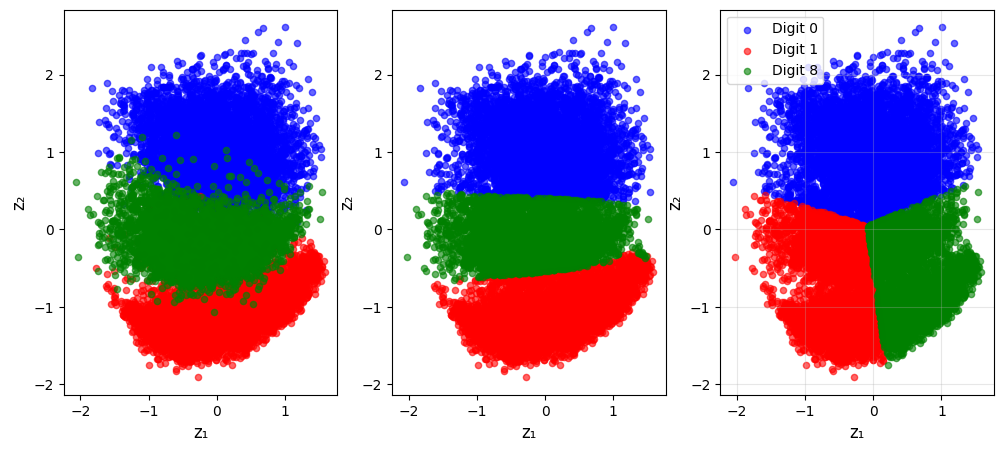

In [238]:
from sklearn.cluster import KMeans

riemann_labels_np = np.vectorize(cluster_to_digit.get)(riemann_labels)
kmeans_eucl = KMeans(n_clusters=K, n_init=10)


eucl_labels = kmeans_eucl.fit_predict(training_latents.cpu().numpy())
eucl_labels = np.vectorize(cluster_to_digit.get)(eucl_labels)

eucl_centers = torch.tensor(kmeans_eucl.cluster_centers_)

labels = [true_train_labels,riemann_labels_np,eucl_labels]
fig,axs = plt.subplots(nrows=1,ncols=3,figsize=(12,5))
for i in range(3):
    plot_latent_space(vae_model,training_latents.cpu().numpy(),labels[i],axs[i])

In [225]:
import torch
import numpy as np
from sklearn.cluster import KMeans

@torch.no_grad()
def fit_land_mixture_loader(
    z_loader,
    vae_model,
    n_components=10,
    reg=1e-4,
    device="cuda"
):
    """
    Apprend un mélange LAND à partir d'un DataLoader de latents.
    """

    vae_model.eval()

    # --------------------------------------------------
    # 1) Collecte des latents CPU pour KMeans
    # --------------------------------------------------
    Z_all = []
    for z, _ in z_loader:
        Z_all.append(z.cpu())
    Z_all = torch.cat(Z_all, dim=0)     # (N, D)

    Z_np = Z_all.numpy()
    N, D = Z_np.shape

    # --------------------------------------------------
    # 2) KMeans euclidien (init)
    # --------------------------------------------------
    kmeans = KMeans(n_clusters=n_components, n_init=10)
    labels = kmeans.fit_predict(Z_np)

    mus = torch.tensor(
        kmeans.cluster_centers_,
        dtype=torch.float32,
        device=device
    )  # (K, D)

    # --------------------------------------------------
    # 3) Covariances LAND via métrique locale
    # --------------------------------------------------
    covs = []
    logdets = []

    eye = torch.eye(D, device=device)

    for k in range(n_components):
        mu = mus[k]

        G = vae_model.compute_metric_tensor_simple(mu.unsqueeze(0)).squeeze(0)
        G = G + reg * eye

        cov = torch.linalg.inv(G)     # LAND covariance
        logdet = torch.logdet(G)

        covs.append(cov.cpu())
        logdets.append(logdet.item())

    covs = torch.stack(covs)          # (K, D, D)
    logdets = torch.tensor(logdets)

    # --------------------------------------------------
    # 4) Poids du mélange
    # --------------------------------------------------
    weights = np.bincount(labels, minlength=n_components).astype(np.float32)
    weights /= weights.sum()
    weights = torch.tensor(weights)

    return {
        "weights": weights,        # (K,)
        "means": mus.cpu(),        # (K, D)
        "covariances": covs,       # (K, D, D)
        "logdets": logdets         # (K,)
    }


land = fit_land_mixture_loader(
    training_latents_loader,
    vae_model,
    n_components=3,
    reg=1e-4,
    device="cuda"
)

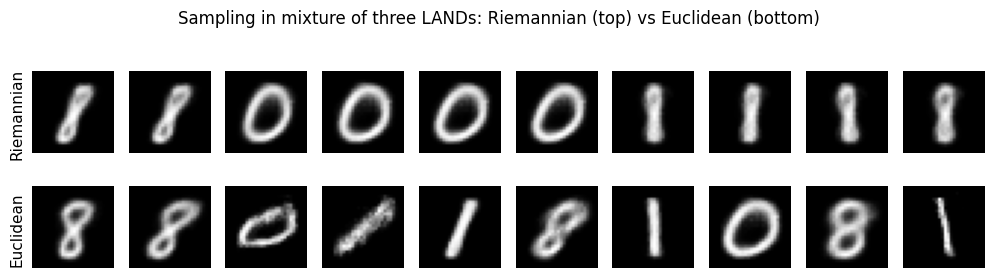

In [226]:
def sample_land_mixture(land, n_samples):
    """
    Sampling from LAND mixture (riemanian)
    """
    weights = land["weights"]
    means = land["means"]
    covs = land["covariances"]

    K, D = means.shape

    comps = torch.multinomial(weights, n_samples, replacement=True)

    samples = []
    for k in range(K):
        nk = (comps == k).sum().item()
        if nk == 0:
            continue

        dist = torch.distributions.MultivariateNormal(
            means[k],
            covariance_matrix=covs[k]
        )
        samples.append(dist.sample((nk,)))

    return torch.cat(samples, dim=0)

def sample_euclidean_mixture(land, n_samples):
    """
    Sampling from LAND mixture (euclidean).
    """
    weights = land["weights"]
    means = land["means"]

    K, D = means.shape

    comps = torch.multinomial(weights, n_samples, replacement=True)

    samples = []
    for k in range(K):
        nk = (comps == k).sum().item()
        if nk == 0:
            continue

        dist = torch.distributions.MultivariateNormal(
            means[k],
            covariance_matrix=torch.eye(D)
        )
        samples.append(dist.sample((nk,)))

    return torch.cat(samples, dim=0)

import matplotlib.pyplot as plt

def plot_land_vs_euclidean(
    vae_model,
    land,
    n_samples=2000,
    dims=(0, 1)
):
    vae_model.eval()
    z_land = sample_land_mixture(land, n_samples)
    img_land = vae_model.decode(z_land)
    z_eucl = sample_euclidean_mixture(land, n_samples)
    img_eucl = vae_model.decode(z_eucl)

    d0, d1 = dims

    fig,axs = plt.subplots(nrows=2,ncols=n_samples,figsize=(10,3))

    for i in range(n_samples):
      axs[0,i].imshow(img_land[i].detach().squeeze().cpu().numpy(),cmap="gray")
      axs[0,i].set_aspect("equal")
      axs[0,i].axis('off')
    axs[0, 0].text(-8, 14, 'Riemannian', fontsize=11, rotation=90, va='center')

    for i in range(n_samples):
      axs[1,i].imshow(img_eucl[i].detach().squeeze().cpu().numpy(),cmap="gray")
      axs[1,i].set_aspect("equal")
      axs[1,i].axis('off')
    axs[1, 0].text(-8, 14, 'Euclidean', fontsize=11, rotation=90, va='center')
    plt.suptitle('Sampling in mixture of three LANDs: Riemannian (top) vs Euclidean (bottom)', fontsize=12)
    plt.tight_layout()


    plt.show()

plot_land_vs_euclidean(
    vae_model.cpu(),
    land,
    n_samples=10,
    dims=(0, 1)
)

In [239]:
def plot_volume_distortion(model, test_loader, save_path='figure_volume_distortion.png'):
    """
    Visualize volume distortion: sqrt(det(M)) shows how volumes are stretched/compressed.
    Important for understanding the geometry of the learned manifold.
    """
    model.eval()

    latents = []
    with torch.no_grad():
        for data, label in test_loader:
            data = data.to(device)
            mu, _ = model.encode(data)
            latents.append(mu.cpu())
    latents = torch.cat(latents, dim=0).numpy()

    grid_size = 100
    x_min, x_max = latents[:, 0].min() - 1, latents[:, 0].max() + 1
    y_min, y_max = latents[:, 1].min() - 1, latents[:, 1].max() + 1
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)
    Z_grid = np.stack([X.ravel(), Y.ravel()], axis=1)

    print("  Computing volume distortion...")
    vol_factors = []

    z_tensor = torch.FloatTensor(Z_grid).to(device)
    batch_size = 100

    for i in range(0, len(z_tensor), batch_size):
        batch = z_tensor[i:i+batch_size]
        M = model.compute_metric_tensor_simple(batch)
        det = torch.det(M)
        vol = torch.sqrt(torch.abs(det))  # Volume element
        vol_factors.append(vol.cpu().numpy())

    vol_factors = np.concatenate(vol_factors).reshape(grid_size, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Linear scale
    im1 = axes[0].contourf(X, Y, vol_factors, levels=30, cmap='plasma')
    axes[0].scatter(latents[:, 0], latents[:, 1], c='white', s=1, alpha=0.5)
    axes[0].set_xlabel('z₁', fontsize=12)
    axes[0].set_ylabel('z₂', fontsize=12)
    axes[0].set_title('Volume Distortion: √det(M)', fontsize=13)
    plt.colorbar(im1, ax=axes[0], label='Volume Factor')

    # Log scale for better contrast
    im2 = axes[1].contourf(X, Y, np.log10(vol_factors + 1e-6), levels=30, cmap='plasma')
    axes[1].scatter(latents[:, 0], latents[:, 1], c='white', s=1, alpha=0.5)
    axes[1].set_xlabel('z₁', fontsize=12)
    axes[1].set_ylabel('z₂', fontsize=12)
    axes[1].set_title('Log Volume Distortion: log₁₀(√det(M))', fontsize=13)
    plt.colorbar(im2, ax=axes[1], label='log₁₀(Volume Factor)')

    plt.tight_layout()
    plt.show()

In [241]:
vae_model.add_rbf(rbf_model)

  Computing volume distortion...


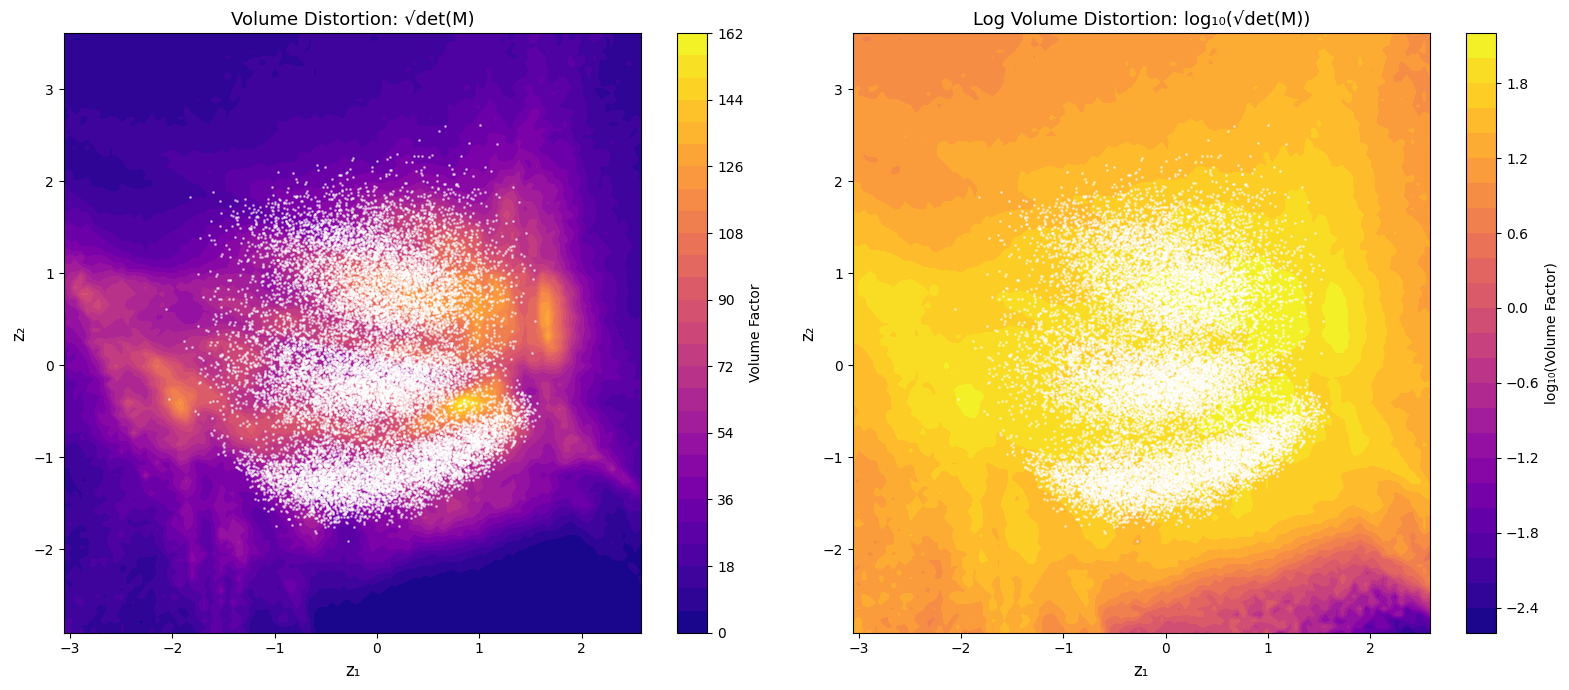

In [242]:
plot_volume_distortion(vae_model,train_loader)